In [4]:
from google.colab import files
import os

uploaded = files.upload()

DATA_DIR = '/content/' + list(uploaded.keys())[0]

print("Uploaded:", DATA_DIR)

Saving cifar-10-python.tar.gz to cifar-10-python.tar.gz
Uploaded: /content/cifar-10-python.tar.gz


In [5]:
import pickle
import numpy as np
import os
import tarfile

tar_path = '/content/cifar-10-python.tar.gz'
extract_path = '/content'

with tarfile.open(tar_path, 'r:gz') as tar:
    tar.extractall(extract_path)

DATA_DIR = '/content/cifar-10-batches-py'


def load_batch(f):
    with open(f, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
        x = d[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        y = np.array(d[b'labels'])
        return x, y


xtr, ytr = [], []

for i in range(1, 6):
    x, y = load_batch(
        os.path.join(DATA_DIR, f'data_batch_{i}')
    )
    xtr.append(x)
    ytr.append(y)

x_train = np.concatenate(xtr)
y_train = np.concatenate(ytr)

x_test, y_test = load_batch(
    os.path.join(DATA_DIR, 'test_batch')
)

classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print(x_train.shape, x_test.shape)

/tmp/ipykernel_5061/2865922799.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


(50000, 32, 32, 3) (10000, 32, 32, 3)


## Task 1: Dataset Preparation

In [6]:
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

import tensorflow as tf
y_train_c = tf.keras.utils.to_categorical(y_train, 10)
y_test_c = tf.keras.utils.to_categorical(y_test, 10)

print('Train:', x_train.shape, y_train_c.shape)
print('Test :', x_test.shape, y_test_c.shape)

Train: (50000, 32, 32, 3) (50000, 10)
Test : (10000, 32, 32, 3) (10000, 10)


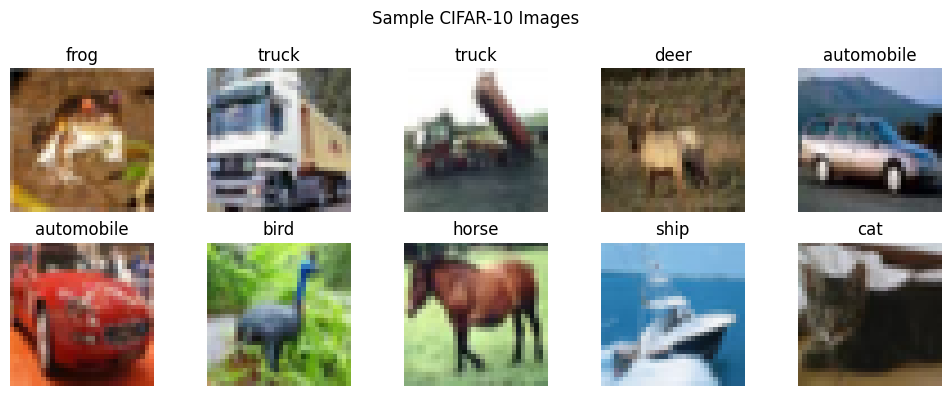

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i]); plt.title(classes[y_train[i][0] if y_train.ndim>1 else y_train[i]]); plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images'); plt.tight_layout(); plt.savefig('sample_images.png'); plt.show()

## Task 2: Transfer Learning Model (MobileNetV2)

In [8]:
from tensorflow.keras import layers, models, optimizers

IMG_SIZE = 96
base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3), include_top=False, weights='imagenet')
base.trainable = False  # freeze convolutional base

inputs = layers.Input(shape=(32,32,3))
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x*255.0)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Task 3: Model Training (frozen base)

In [11]:
aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
])
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_c)).shuffle(5000).batch(128)
train_ds = train_ds.map(lambda x,y: (aug(x, training=True), y)).prefetch(1)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_c)).batch(32).prefetch(1)

hist1 = model.fit(train_ds, validation_data=test_ds, epochs=10)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.8758 - loss: 0.3506 - val_accuracy: 0.8764 - val_loss: 0.3990
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.8741 - loss: 0.3504 - val_accuracy: 0.8715 - val_loss: 0.4022
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.8769 - loss: 0.3456 - val_accuracy: 0.8735 - val_loss: 0.4074
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.8765 - loss: 0.3440 - val_accuracy: 0.8714 - val_loss: 0.4236
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.8791 - loss: 0.3400 - val_accuracy: 0.8713 - val_loss: 0.4164
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.8811 - loss: 0.3313 - val_accuracy: 0.8736 - val_loss: 0.4103
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.8812 - loss: 0.3324 - val_accuracy: 0.8716 - val_loss: 0.4225
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.8841 - loss: 0.3285 - 

## Task 4: Fine Tuning (unfreeze last block)

In [15]:
base.trainable = True

for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    mode='max',
    restore_best_weights=True
)

hist2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=8,
    callbacks=[early_stop]
)

Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 75ms/step - accuracy: 0.8554 - loss: 0.4373 - val_accuracy: 0.8719 - val_loss: 0.4626
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.8619 - loss: 0.4075 - val_accuracy: 0.8723 - val_loss: 0.4531
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.8655 - loss: 0.3914 - val_accuracy: 0.8746 - val_loss: 0.4374
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.8732 - loss: 0.3661 - val_accuracy: 0.8773 - val_loss: 0.4340
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.8739 - loss: 0.3577 - val_accuracy: 0.8787 - val_loss: 0.4237
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.8800 - loss: 0.3441 - val_accuracy: 0.8798 - val_loss: 0.4174
Epoch 7/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.8870 - loss: 0.3273 - val_accuracy: 0.8803 - val_loss: 0.4141
Epoch 8/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.8897 - loss: 0.3133 - val_accu

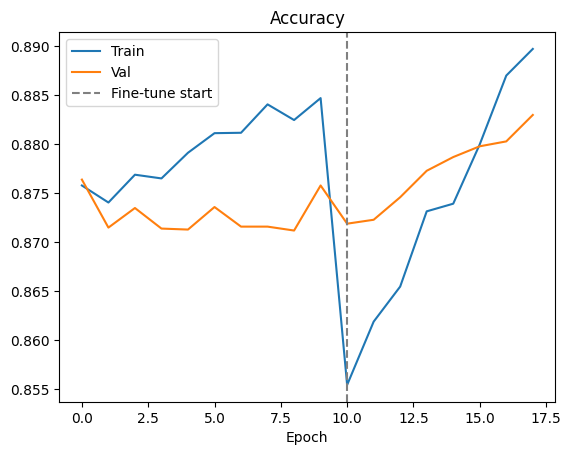

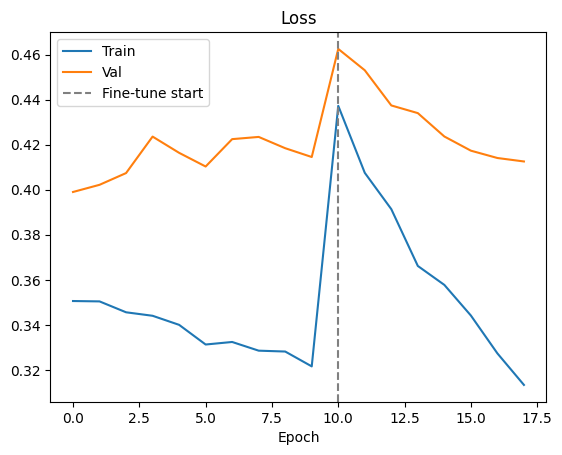

Before fine-tuning val acc: 0.876
After fine-tuning val acc : 0.883


In [16]:
def merge(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc = merge(hist1, hist2, 'accuracy'); val_acc = merge(hist1, hist2, 'val_accuracy')
loss = merge(hist1, hist2, 'loss'); val_loss = merge(hist1, hist2, 'val_loss')

plt.figure(); plt.plot(acc, label='Train'); plt.plot(val_acc, label='Val')
plt.axvline(10, ls='--', c='gray', label='Fine-tune start')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend(); plt.savefig('accuracy.png'); plt.show()

plt.figure(); plt.plot(loss, label='Train'); plt.plot(val_loss, label='Val')
plt.axvline(10, ls='--', c='gray', label='Fine-tune start')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend(); plt.savefig('loss.png'); plt.show()

print(f'Before fine-tuning val acc: {val_acc[9]:.3f}')
print(f'After fine-tuning val acc : {val_acc[-1]:.3f}')

## Task 5: Model Evaluation

157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step
              precision    recall  f1-score   support

    airplane       0.88      0.92      0.90      1000
  automobile       0.93      0.95      0.94      1000
        bird       0.89      0.86      0.88      1000
         cat       0.81      0.73      0.77      1000
        deer       0.87      0.84      0.85      1000
         dog       0.84      0.81      0.83      1000
        frog       0.86      0.94      0.90      1000
       horse       0.88      0.92      0.90      1000
        ship       0.94      0.92      0.93      1000
       truck       0.91      0.93      0.92      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



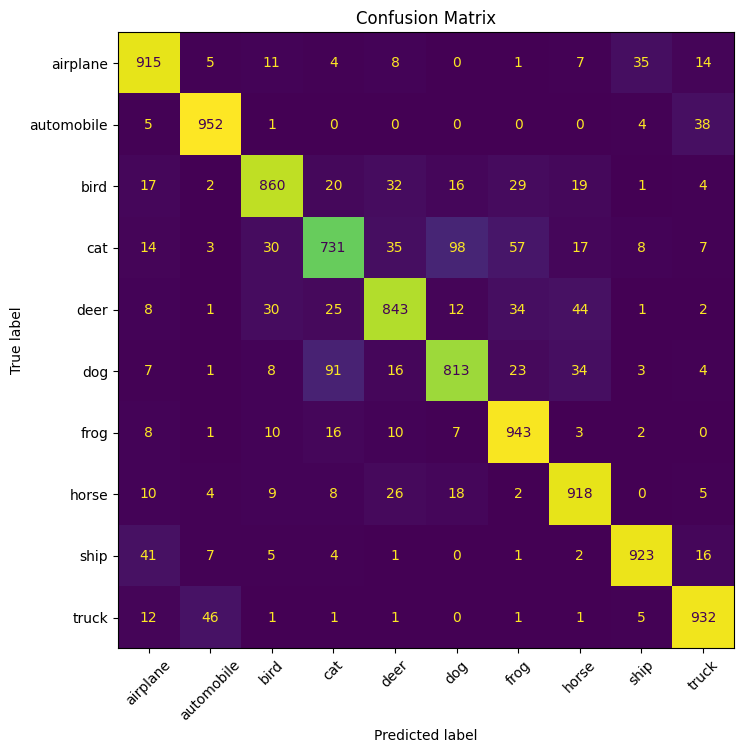

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(x_test, batch_size=64).argmax(1)
y_true = y_test.flatten()

print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix'); plt.savefig('confusion_matrix.png'); plt.show()

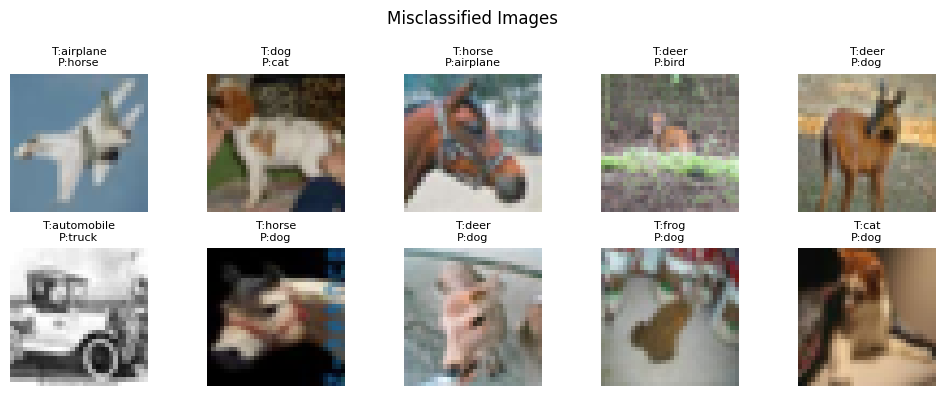

In [18]:
wrong = np.where(y_pred != y_true)[0][:10]
plt.figure(figsize=(10,4))
for i, idx in enumerate(wrong):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx]); plt.axis('off')
    plt.title(f'T:{classes[y_true[idx]]}\nP:{classes[y_pred[idx]]}', fontsize=8)
plt.suptitle('Misclassified Images'); plt.tight_layout(); plt.savefig('misclassified.png'); plt.show()

## 18. Results Summary

In [21]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

test_loss, test_acc = model.evaluate(test_ds, verbose=0)

y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
y_true = np.argmax(y_test_c, axis=1)

prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

total_params = model.count_params()

print(f'Training Accuracy : {acc[-1]:.3f}')
print(f'Testing Accuracy  : {test_acc:.3f}')
print(f'Precision (macro) : {prec:.3f}')
print(f'Recall (macro)    : {rec:.3f}')
print(f'F1-score (macro)  : {f1:.3f}')
print(f'Total Parameters  : {total_params:,}')

Training Accuracy : 0.890
Testing Accuracy  : 0.883
Precision (macro) : 0.882
Recall (macro)    : 0.883
F1-score (macro)  : 0.882
Total Parameters  : 2,588,490


### 18.2 Comparison of CNN Architectures (from literature + this run)

| Model | Parameters | Accuracy (%) | Notes |
|---|---|---|---|
| LeNet-5 | 60K | ~65 | Shallow, fast, weak on complex images |
| AlexNet | 61M | ~75 | ReLU + Dropout breakthrough |
| VGG16 | 138M | ~85 | Deep, uniform 3×3 filters, heavy |
| GoogleNet | 6.8M | ~88 | Inception modules, efficient |
| **MobileNetV2 (this experiment)** | see above | see above | Transfer learning, lightweight, fast convergence |
